In [1]:
%load_ext autoreload
%autoreload 2

import sys
print(sys.executable)

from varengine.data import load_prices
from varengine.returns import simple_returns, portfolio_losses
print("imports OK")

C:\Users\Antonio\Desktop\TSE\ZZ OTHER\Market Risk Engine\market-risk-engine\.venv\Scripts\python.exe
imports OK


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from varengine.data import load_prices
from varengine.returns import simple_returns, portfolio_losses

from varengine.config import TICKERS, START, END
prices = load_prices(TICKERS, START, END)

rets = simple_returns(prices)
w = np.full(len(TICKERS), 1 / len(TICKERS))
loss = portfolio_losses(rets, w)

Loaded cached prices: 2015-01-02 to 2026-09-18


In [3]:
print(prices.shape)
print(prices.tail())

(2996, 6)
            SAN.MC    BBVA.MC     IBE.MC     ITX.MC  TEF.MC     REP.MC
Date                                                                  
2026-09-11  12.886  25.410000  20.160000  54.020000   3.653  28.920000
2026-09-14  12.772  25.080000  19.715000  53.720001   3.674  28.500000
2026-09-15  12.666  24.900000  20.040001  52.580002   3.688  29.379999
2026-09-16  12.690  24.719999  20.240000  52.779999   3.707  29.190001
2026-09-18  12.690  24.719999  20.240000  51.740002   3.707  29.190001


skewness:  0.5179318302121959
excess kurtosis: 14.96427668688072
SignificanceResult(statistic=np.float64(28078.448245921096), pvalue=np.float64(0.0))


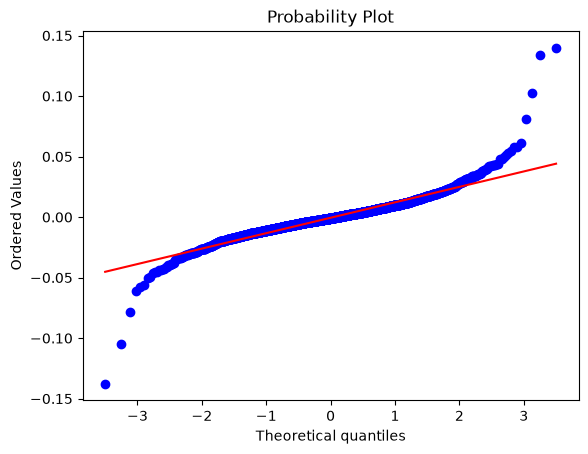

In [4]:
# Stylised fact 1: heavy tails
print("skewness: ", stats.skew(loss))
print("excess kurtosis:", stats.kurtosis(loss)) # 0 under normality
print(stats.jarque_bera(loss)) # H0: normal

stats.probplot(loss, dist="norm", plot=plt) # QQ plot vs normal
plt.show()

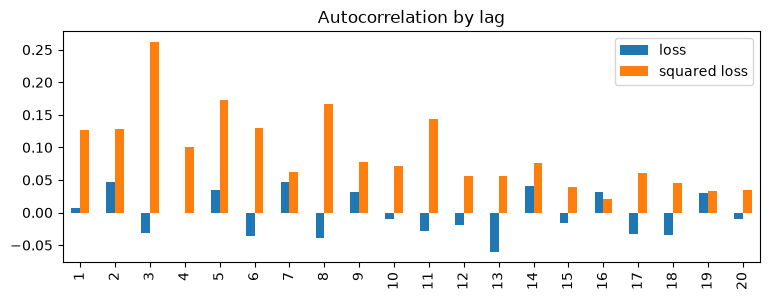

In [5]:
# Stylised fact 2: volatility clustering
lags = range(1, 21)
acf = pd.DataFrame({
"loss": [loss.autocorr(k) for k in lags],
"squared loss": [(loss**2).autocorr(k) for k in lags],
}, index=lags)
acf.plot.bar(figsize=(9, 3), title="Autocorrelation by lag")
plt.show()